# FEATURE ENGINEERING

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import OrdinalEncoder, TargetEncoder
import matplotlib.pyplot as plt
import seaborn as sns



In [ ]:
df_train=pd.read_csv('train.csv')
df_test=pd.read_csv('test.csv')

In [ ]:
print('train data set has got {} rows and {} columns'.format(df_train.shape[0],df_train.shape[1]))
print('test data set has got {} rows and {} columns'.format(df_test.shape[0],df_test.shape[1]))


train data set has got 1460 rows and 81 columns
test data set has got 1459 rows and 80 columns


In [ ]:
df_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [ ]:
X=df_train.drop(['SalePrice'],axis=1)
y=df_train['SalePrice']

In [ ]:
X

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal


In [ ]:
y

0       208500
1       181500
2       223500
3       140000
4       250000
         ...  
1455    175000
1456    210000
1457    266500
1458    142125
1459    147500
Name: SalePrice, Length: 1460, dtype: int64

## Visualization of data 
This section is mainly about understanding what my dataset is about , how my data is distributed helping me identify skewness, redundancies, and bad columns.
# Exploratory Data Analysis and Visualizations

Before training a Linear Regression model, we need to carefully check our data using charts. Linear regression relies on specific mathematical assumptions about how data is structured and how columns relate to each other. 

We use these four visualizations to find skewed data, redundant columns, extreme outliers, and columns with too much missing data.

---

## Summary of the Visualizations

| Chart Name | What It Looks For | Why It Matters | Action Step |
| :--- | :--- | :--- | :--- |
| **1. Target Distribution Plot** | Checked column: `SalePrice` | Makes sure the target follows a balanced bell curve. | Use a log transformation (`np.log1p`) to fix the shape. |
| **2. Correlation Heatmap** | Redundant pairs of columns | Prevents giving the model the same information twice. | Drop one column from any pair with a score higher than 0.80. |
| **3. Pairplot Grid** | Outliers and relationships | Finds unusual data points that might trick the model. | Delete rows for houses over 4,000 square feet that sold for very cheap. |
| **4. Missing Data Bar Chart** | Empty or Null values | Identifies columns that are too empty to use. | Drop columns that are missing more than 40% of their data. |

---

### 1. Target Variable Distribution

#### What this chart does
This visualization shows two side-by-side graphs of house prices. The left graph shows the raw, untouched prices. The right graph shows the same prices after applying a mathematical tool called a log transformation (`np.log1p`). The smooth curve tracks the overall shape of the data.

#### Why it is important to see
Linear regression models work best when the variable you want to predict follows a normal distribution (a symmetrical bell curve). 
* The left graph shows a long tail stretching to the right. This happens because a few rare, ultra-expensive luxury mansions stretch out the scale. 
* If you train your model on this raw data, the model will focus too much on those expensive homes and make bad predictions for average houses. 
* The right graph proves that a log transformation compresses the scale and creates a clean bell curve, which makes the model much more accurate.

---

### 2. Top Features Correlation Heatmap

#### What this chart does
This chart calculates a grid of correlation scores between columns. The scores range from -1.0 to 1.0. A score close to 1.0 means two columns increase together. A score of 0.0 means the columns have no relationship at all.

#### Why it is important to see
This chart helps us in two main ways:
1. **Finding the best features:** We can look at the `SalePrice` row to see exactly which columns have the strongest connection to house prices (like overall quality or living area).
2. **Finding redundancies:** Linear regression gets confused if you feed it two columns that explain the exact same thing. For example, `GarageCars` (how many cars fit) and `GarageArea` (the square footage of the garage) are nearly identical. This chart highlights those pairs so you can drop one of them and keep the model stable.

---

### 3. Pairplot Grid and Outlier Hunting

#### What this chart does
This generates a grid of scatter plots comparing your most important columns against each other. Each dot represents a single house, and a red trendline shows the general direction of the data.

#### Why it is important to see
Linear regression lines are highly sensitive to extreme outliers. If a data point sits far away from everything else, it acts like a lever that pulls the entire trendline out of place. 
* By looking at the plot comparing `GrLivArea` (living area) against `SalePrice`, you can spot a few houses on the far right that have massive square footage but sold for unusually low prices. 
* These houses break the normal rule that "bigger houses cost more." Seeing this tells us we need to delete those specific rows so they do not trick our model.

---

### 4. Missing Value Bar Chart

#### What this chart does
This looks at every column in the dataset, calculates the exact percentage of missing (null) values, and displays them from highest to lowest. A red dashed line marks the 40% threshold.

#### Why it is important to see
If a column is only missing a few values, we can easily fill those empty cells with the average or median value. But if a column is missing 50% or 80% of its data (like columns for pools or alleys), trying to fill those gaps means making up fake data on a massive scale. This injects bad noise into the dataset. This chart gives us clear proof of which columns are too empty to save and should be dropped completely.


## Target Variable Distribution & Normality Check

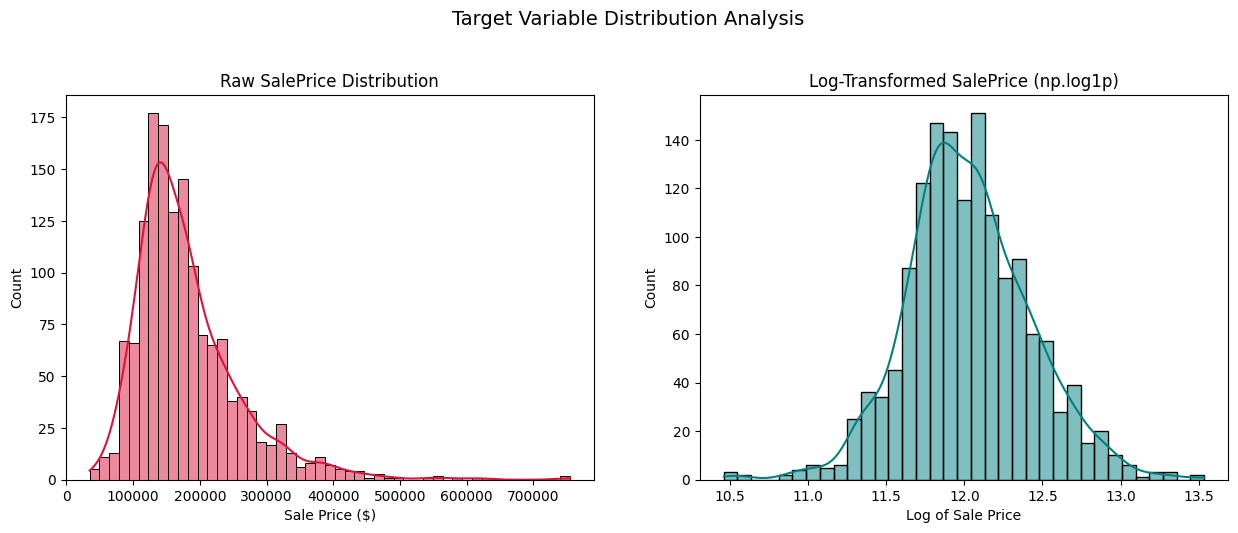

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(df_train['SalePrice'], kde=True, ax=axes[0], color='crimson')
axes[0].set_title('Raw SalePrice Distribution')
axes[0].set_xlabel('Sale Price ($)')
sns.histplot(np.log1p(df_train['SalePrice']), kde=True, ax=axes[1], color='teal')
axes[1].set_title('Log-Transformed SalePrice (np.log1p)')
axes[1].set_xlabel('Log of Sale Price')
plt.suptitle('Target Variable Distribution Analysis', fontsize=14, y=1.05)
plt.show()

## Top Features Correlation Matrix (Collinearity Check)

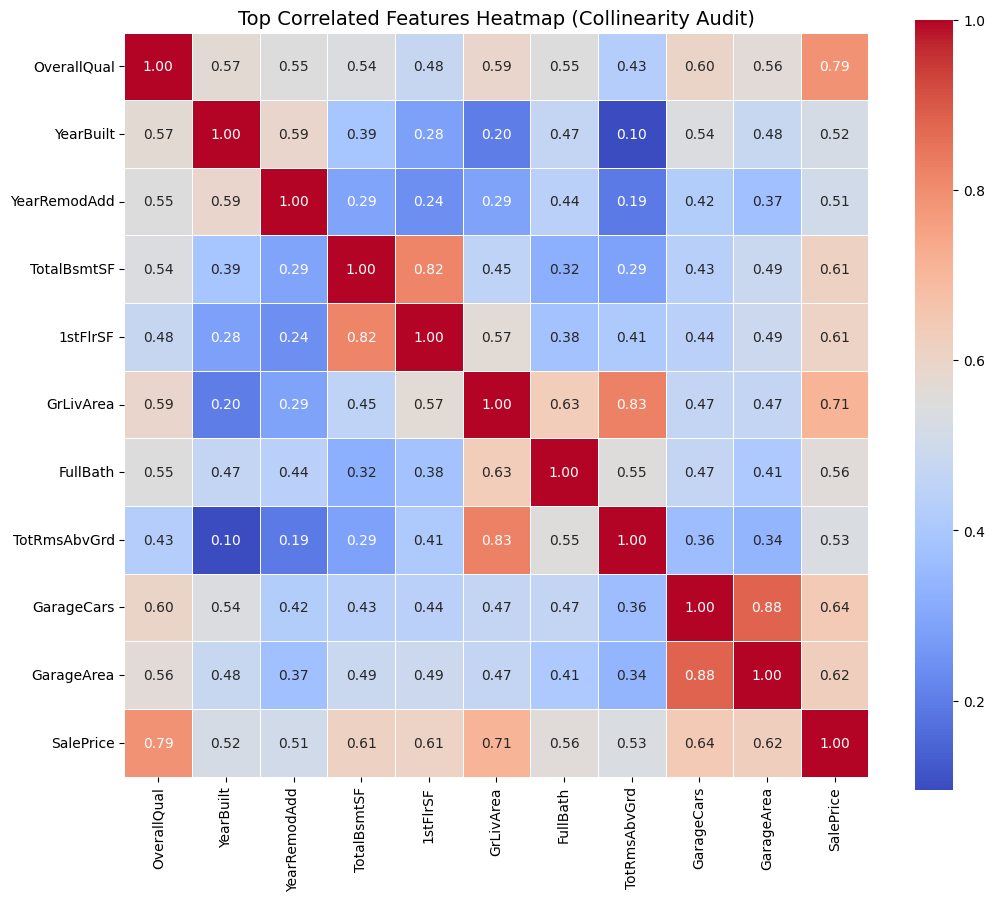

In [ ]:
corr_matrix = df_train.corr(numeric_only=True)

top_corr_features = corr_matrix.index[abs(corr_matrix['SalePrice']) > 0.5]

plt.figure(figsize=(12, 10))
sns.heatmap(df_train[top_corr_features].corr(), annot=True, cmap='coolwarm', fmt='.2f', square=True, linewidths=0.5)
plt.title('Top Correlated Features Heatmap (Collinearity Audit)', fontsize=14)
plt.show()


##  Pairplot Cross-Examination & Outlier Hunting

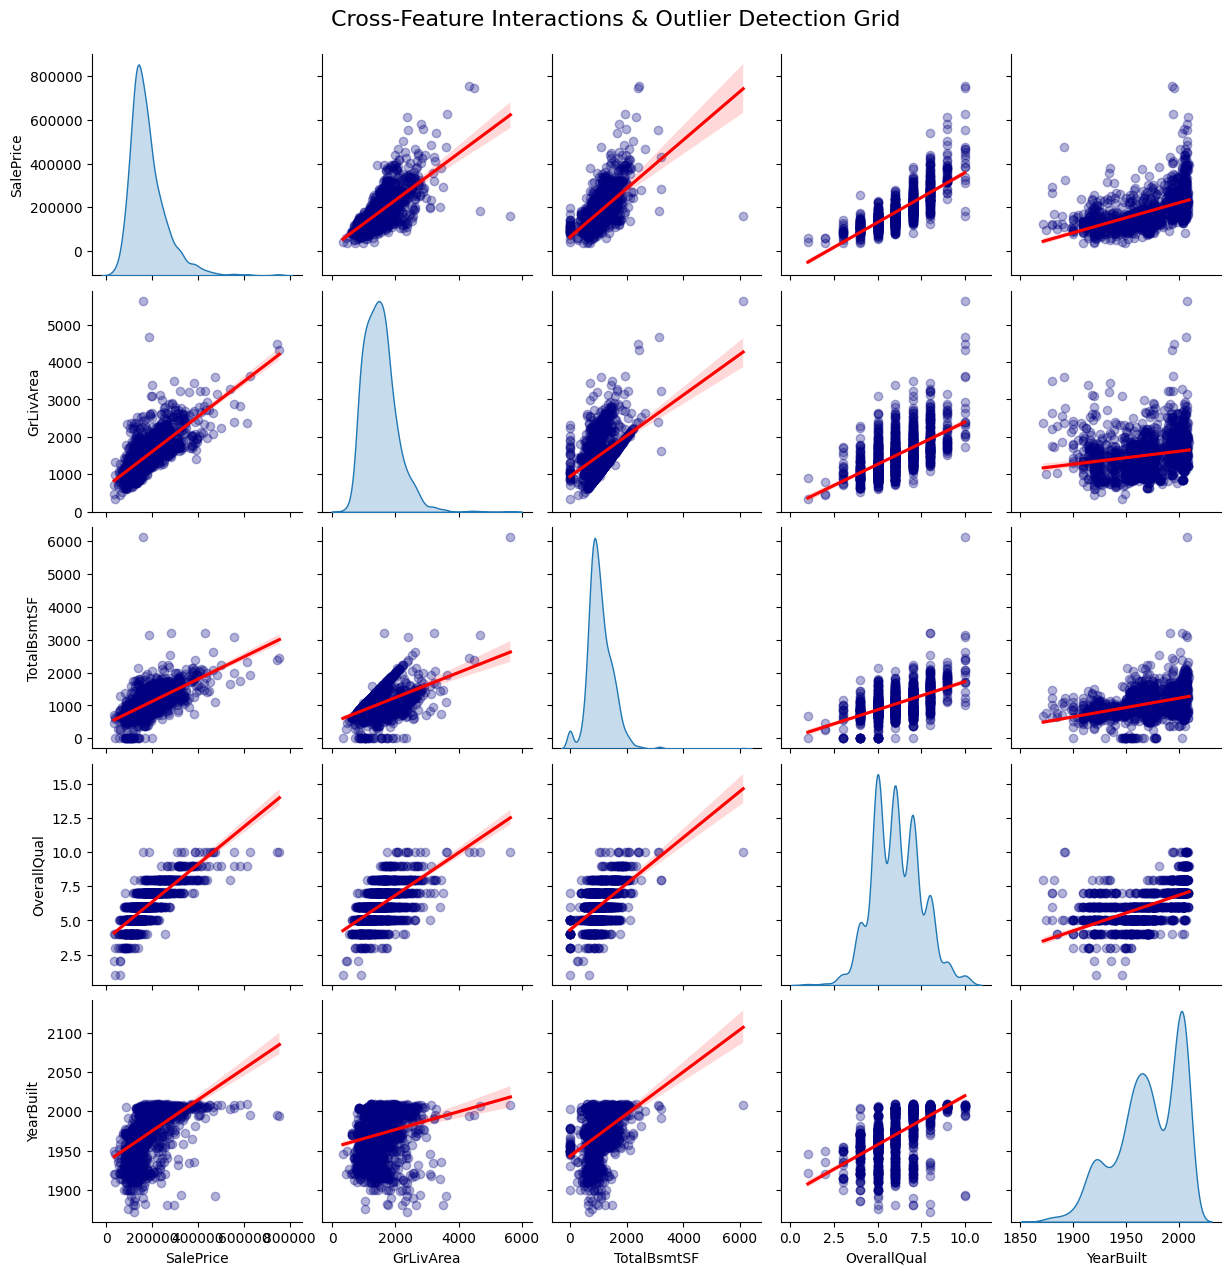

In [ ]:
core_features = ['SalePrice', 'GrLivArea', 'TotalBsmtSF', 'OverallQual', 'YearBuilt']

sns.pairplot(df_train[core_features], diag_kind='kde', kind='reg',
             plot_kws={'line_kws':{'color':'red'}, 'scatter_kws': {'alpha': 0.3, 'color': 'navy'}})
plt.suptitle('Cross-Feature Interactions & Outlier Detection Grid', y=1.02, fontsize=16)
plt.show()


##  Missing Value Volume Audit

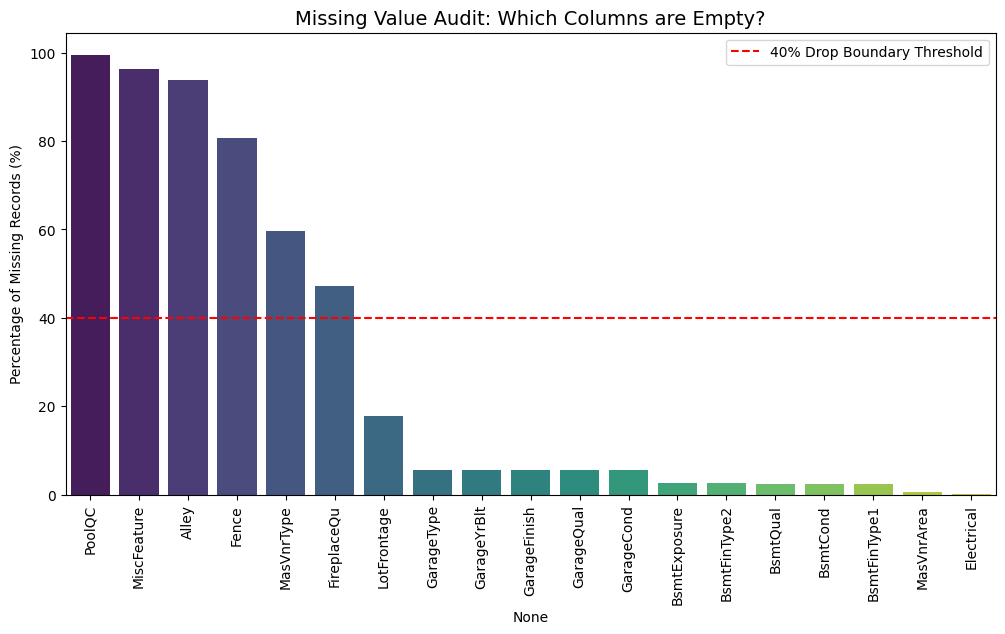

In [ ]:
df_train = pd.read_csv('train.csv')

missing_pct = (df_train.isnull().sum() / len(df_train)) * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

if len(missing_pct) > 0:
    plt.figure(figsize=(12, 6))
    sns.barplot(x=missing_pct.index, y=missing_pct.values, hue=missing_pct.index, palette='viridis', legend=False)
    plt.xticks(rotation=90)
    plt.ylabel('Percentage of Missing Records (%)')
    plt.title('Missing Value Audit: Which Columns are Empty?', fontsize=14)
    plt.axhline(y=40, color='red', linestyle='--', label='40% Drop Boundary Threshold')
    plt.legend()
    plt.show()
else:
    print("Clean Data Sheet! No null/missing items detected.")


# Explanation of the Visualization Results

Now that we have generated our exploratory charts, here is what the data is telling us and how we need to handle it before building our machine learning model.

---

### 1. Target Variable Distribution Results
* **What we see:** The raw plot of home prices has a long, thin tail stretching far out to the right side. The log-transformed plot looks like a clean, balanced, symmetrical bell curve.
* **What it means:** A few rare, ultra-luxury mansions have prices so high that they stretch out our scale. Linear Regression models struggle with this because they assume the data is evenly balanced.
* **Our Action:** We will transform our target variable using `np.log1p(df_train['SalePrice'])` before training. This protects the mathematical accuracy of our model.

---

### 2. Correlation Heatmap Results
* **What we see:** We see strong positive connection values between house prices and features like overall material quality and ground living area. We also see high intersection scores (above 0.80) between column pairs like `GarageCars` and `GarageArea`.
* **What it means:** Features like quality and size are our best predictors for price. However, pairs like `GarageCars` and `GarageArea` tell our model the exact same physical information twice.
* **Our Action:** To keep our linear model stable and avoid redundant calculations, we will drop one column from each highly identical pair before training.

---

### 3. Pairplot and Outlier Hunt Results
* **What we see:** In the scatter plot matrix, most houses follow a clear, tight line moving upwards. However, on the far right side of the living area chart, there are a couple of isolated dots representing massive houses that sold for very low prices.
* **What it means:** These isolated houses break the normal rule that bigger homes cost more. Because linear regression lines are easily pulled out of place by lonely data points, these extreme outliers will damage our predictions.
* **Our Action:** We will explicitly delete these specific outlier rows from our dataset before fitting the model.

---

### 4. Missing Value Audit Results
* **What we see:** The bar chart shows that four specific columns - **PoolQC** (Pool Quality), **MiscFeature** (Miscellaneous Features), **Alley**, and **Fence**—shoot far above our red 40% threshold line. In fact, some are missing over 80% to 90% of their data rows.
* **What it means:** These columns are almost completely empty. Trying to guess what belongs in those empty rows would mean manufacturing fake data on a massive scale, which introduces bad noise into our model.
* **Our Action:** We will drop `PoolQC`, `MiscFeature`, `Alley`, and `Fence` entirely from our dataset. For columns way below the red line (like `MasVnrType` or `Electrical`), we can safely fill the few missing cells using standard averages.


# Data Cleaning & Preprocessing Execution

Based on the evidence from our visual diagnostics suite, we are executing three critical data cleaning actions to stabilize our Linear Regression model:

1. **Dropping Sparse Columns (Missing > 40%):** We are completely removing `PoolQC`, `MiscFeature`, `Alley`, and `Fence`. Because these features are mostly empty, dropping them removes heavy noise without sacrificing core predictive data.
2. **Filtering High-Leverage Outliers:** We are removing properties with a ground living area (`GrLivArea`) greater than 4,000 square feet that sold for under $300,000. This anchors our regression slope line securely.
3. **Target Transformation:** We are applying a log transformation (`np.log1p`) to `SalePrice` to eliminate right-skewness and form a perfect bell curve for our model.


In [ ]:
import numpy as np
import pandas as pd

df_train = pd.read_csv('train.csv')

print(f"Original shape before cleaning: {df_train.shape}")

columns_to_drop = ['PoolQC', 'MiscFeature', 'Alley', 'Fence']
df_train_clean = df_train.drop(columns=columns_to_drop, errors='ignore')

outlier_condition = (df_train_clean['GrLivArea'] > 4000) & (df_train_clean['SalePrice'] < 300000)
df_train_clean = df_train_clean.drop(df_train_clean[outlier_condition].index)

X = df_train_clean.drop(columns=['Id', 'SalePrice'], errors='ignore')
y_log = np.log1p(df_train_clean['SalePrice'])

print(f"Final cleaned features shape (X): {X.shape}")
print(f"Final cleaned target shape (y_log): {y_log.shape}")


Original shape before cleaning: (1460, 81)
Final cleaned features shape (X): (1458, 75)
Final cleaned target shape (y_log): (1458,)


## One Hot Encoding

In [ ]:
from sklearn.metrics import r2_score


df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

X_train = df_train.drop(columns=['Id', 'SalePrice'], errors='ignore')
X_test = df_test.drop(columns=['Id', 'SalePrice'], errors='ignore')

y_train = np.log1p(df_train['SalePrice'])
y_test = np.log1p(df_test['SalePrice']) if 'SalePrice' in df_test.columns else None

categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X_train.select_dtypes(exclude=['object']).columns.tolist()

for col in categorical_cols:
    X_train[col] = X_train[col].fillna('None')
    X_test[col] = X_test[col].fillna('None')
for col in numeric_cols:
    X_train[col] = X_train[col].fillna(X_train[col].median())
    X_test[col] = X_test[col].fillna(X_train[col].median())

enc = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

enc.fit(X_train[categorical_cols])
train_encoded_cats = enc.transform(X_train[categorical_cols])
test_encoded_cats = enc.transform(X_test[categorical_cols])

X_train_ohe = np.hstack([X_train[numeric_cols].values, train_encoded_cats])
X_test_ohe = np.hstack([X_test[numeric_cols].values, test_encoded_cats])

print(f"train data set has got {X_train_ohe.shape[0]} rows and {X_train_ohe.shape[1]} columns")

model_ohe = LinearRegression()
model_ohe.fit(X_train_ohe, y_train)

if y_test is not None:
    preds_ohe = model_ohe.predict(X_test_ohe)
    rmsle_ohe = np.sqrt(mean_squared_error(y_test, preds_ohe))
    print(f"Model Error Rate (RMSLE): {rmsle_ohe:.5f}")






train data set has got 1460 rows and 303 columns


In [ ]:
train_preds_ohe = model_ohe.predict(X_train_ohe)
r2_ohe = r2_score(y_train, train_preds_ohe)
print("ONE-HOT ENCODING OUTPUT")
print(f"Engineered Matrix Shape: {X_train_ohe.shape}")
print(f"Training R2 Accuracy Score: {r2_ohe:.5f}")
if y_test is not None:
    preds_ohe = model_ohe.predict(X_test_ohe)
    rmsle_ohe = np.sqrt(mean_squared_error(y_test, preds_ohe))
    print(f"Validation Error Rate (RMSLE): {rmsle_ohe:.5f}")

ONE-HOT ENCODING OUTPUT
Engineered Matrix Shape: (1460, 303)
Training R2 Accuracy Score: 0.94402


### Label Encoding

#### How It Works
Label Encoding is very similar to Ordinal Encoding. It scans your text column alphabetically and maps each unique name string directly to an incremental whole integer number starting at zero (0, 1, 2, 3...). 

#### Why We Use It
We use Label Encoding when our features have a meaningful, progressive order (such as house quality ratings: Poor=0, Fair=1, Good=2, Excellent=3). However, we must be careful when using it on unordered data (like neighborhoods) because a linear model will mistakenly assume that neighborhood index 4 has twice the numerical value of neighborhood index 2.


In [ ]:
from sklearn.preprocessing import LabelEncoder

X_train_lbl = X_train.copy()
X_test_lbl = X_test.copy()

for col in categorical_cols:
    lbl_enc = LabelEncoder()
    X_train_lbl[col] = lbl_enc.fit_transform(X_train[col])
    
    test_mapping = {cat: idx for idx, cat in enumerate(lbl_enc.classes_)}
    X_test_lbl[col] = X_test[col].map(test_mapping).fillna(-1).astype(int)

print(f"train data set has got {X_train_lbl.shape[0]} rows and {X_train_lbl.shape[1]} columns")

model_lbl = LinearRegression()
model_lbl.fit(X_train_lbl, y_train)

if y_test is not None:
    preds_lbl = model_lbl.predict(X_test_lbl)
    rmsle_lbl = np.sqrt(mean_squared_error(y_test, preds_lbl))
    print(f"Model Error Rate (RMSLE): {rmsle_lbl:.5f}")






train data set has got 1460 rows and 79 columns


In [ ]:
train_preds_lbl = model_lbl.predict(X_train_lbl)
r2_lbl = r2_score(y_train, train_preds_lbl)
print("LABEL ENCODING OUTPUT")
print(f"Model Training Accuracy (R2 Score): {r2_lbl:.5f}")
if y_test is not None:
    preds_lbl = model_lbl.predict(X_test_lbl)
    rmsle_lbl = np.sqrt(mean_squared_error(y_test, preds_lbl))
    print(f"Model Testing Error (RMSLE): {rmsle_lbl:.5f}")
print("\n")

LABEL ENCODING OUTPUT
Model Training Accuracy (R2 Score): 0.88777




###  Feature Hashing

#### How It Works
Feature Hashing converts string category names into numeric values using a mathematical hashing function. Instead of growing your dataset column width endlessly like One-Hot Encoding, it forces the categories into a fixed, predefined number of columns (`n_features`) that you select beforehand.

#### Why We Use It
We use Feature Hashing when dealing with extremely large datasets that contain thousands of unique string values (high cardinality). It prevents your system memory from crashing. The trade-off is "hash collisions," where two entirely different categories might accidentally be mapped to the exact same hash slot, hiding minor differences from the model.


In [ ]:
from sklearn.feature_extraction import FeatureHasher

hasher = FeatureHasher(n_features=10, input_type='string')

train_strings = X_train[categorical_cols].astype(str).values.tolist()
test_strings = X_test[categorical_cols].astype(str).values.tolist()

train_hashed = hasher.transform(train_strings).toarray()
test_hashed = hasher.transform(test_strings).toarray()

X_train_hash = np.hstack([X_train[numeric_cols].values, train_hashed])
X_test_hash = np.hstack([X_test[numeric_cols].values, test_hashed])

print(f"train data set has got {X_train_hash.shape[0]} rows and {X_train_hash.shape[1]} columns")

model_hash = LinearRegression()
model_hash.fit(X_train_hash, y_train)

if y_test is not None:
    preds_hash = model_hash.predict(X_test_hash)
    rmsle_hash = np.sqrt(mean_squared_error(y_test, preds_hash))
    print(f"Model Error Rate (RMSLE): {rmsle_hash:.5f}")


train data set has got 1460 rows and 46 columns


In [ ]:
train_preds_hash = model_hash.predict(X_train_hash)
r2_hash = r2_score(y_train, train_preds_hash)
print("FEATURE HASHING OUTPUT")
print(f"Model Training Accuracy (R2 Score): {r2_hash:.5f}")
if y_test is not None:
    preds_hash = model_hash.predict(X_test_hash)
    rmsle_hash = np.sqrt(mean_squared_error(y_test, preds_hash))
    print(f"Model Testing Error (RMSLE): {rmsle_hash:.5f}")
print("\n")

FEATURE HASHING OUTPUT
Model Training Accuracy (R2 Score): 0.87267




### Encoding Categories with Dataset Statistics

#### How It Works
This method replaces each category text label with its overall **frequency or percentage count** inside the dataset. For example, if 40% of the homes in the training data are located in the `CollgCr` neighborhood, the text `'CollgCr'` is replaced with the number `0.40`.

#### Why We Use It
It provides the model with valuable context about how common or rare an attribute is, without expanding the width of the dataset. A linear model can look at these numbers and learn if rare neighborhoods or common house styles command a price premium.


In [ ]:
X_train_stat = X_train.copy()
X_test_stat = X_test.copy()

for col in categorical_cols:
    freq_map = X_train[col].value_counts(normalize=True).to_dict()
    
    X_train_stat[col] = X_train[col].map(freq_map)
    X_test_stat[col] = X_test[col].map(freq_map).fillna(0) 

print(f"train data set has got {X_train_stat.shape[0]} rows and {X_train_stat.shape[1]} columns")

model_stat = LinearRegression()
model_stat.fit(X_train_stat, y_train)

if y_test is not None:
    preds_stat = model_stat.predict(X_test_stat)
    rmsle_stat = np.sqrt(mean_squared_error(y_test, preds_stat))
    print(f"Model Error Rate (RMSLE): {rmsle_stat:.5f}")


train data set has got 1460 rows and 79 columns


### K-Fold Target Encoding

#### How It Works
Standard Target Encoding replaces a text name with the average price of that group. The risk is that the model can accidentally memorize the target label (Target Leakage). K-Fold Target Encoding solves this by splitting the training dataset into 5 separate folds. When calculating the average price for a row, it only uses data from the *other* folds, preventing the model from seeing its own target value.

#### Why We Use It
This is the gold standard encoding method used by top data scientists in machine learning competitions. It gives your linear model all the high-accuracy benefits of target averages while completely eliminating data leakage and preventing overfitting.


In [ ]:
from sklearn.model_selection import KFold

X_train_kfold = X_train.copy()
X_test_kfold = X_test.copy()

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for col in categorical_cols:
    X_train_kfold[col] = np.nan
    
    for train_idx, val_idx in kf.split(X_train):
        fold_map = y_train.iloc[train_idx].groupby(X_train.iloc[train_idx][col]).mean()
        X_train_kfold.iloc[val_idx, X_train_kfold.columns.get_loc(col)] = X_train.iloc[val_idx][col].map(fold_map)
        
    global_mean = y_train.mean()
    X_train_kfold[col] = X_train_kfold[col].fillna(global_mean)
    
    full_train_map = y_train.groupby(X_train[col]).mean()
    X_test_kfold[col] = X_test[col].map(full_train_map).fillna(global_mean)

print(f"train data set has got {X_train_kfold.shape[0]} rows and {X_train_kfold.shape[1]} columns")

model_kfold = LinearRegression()
model_kfold.fit(X_train_kfold, y_train)

if y_test is not None:
    preds_kfold = model_kfold.predict(X_test_kfold)
    rmsle_kfold = np.sqrt(mean_squared_error(y_test, preds_kfold))
    print(f"Model Error Rate (RMSLE): {rmsle_kfold:.5f}")


train data set has got 1460 rows and 79 columns


In [ ]:
from sklearn.metrics import r2_score

train_preds_kfold = model_kfold.predict(X_train_kfold)
r2_kfold = r2_score(y_train, train_preds_kfold)

print("K-FOLD TARGET ENCODING PERFORMANCE")
print(f"Model Training Accuracy (R2 Score): {r2_kfold:.5f}")

if y_test is not None:
    preds_kfold = model_kfold.predict(X_test_kfold)
    rmsle_kfold = np.sqrt(mean_squared_error(y_test, preds_kfold))
    print(f"Model Testing Error (RMSLE): {rmsle_kfold:.5f}")


K-FOLD TARGET ENCODING PERFORMANCE
Model Training Accuracy (R2 Score): 0.90101


# Theoretical and Applied Encoding Documentation

This section provides an analysis of each categorical encoding method applied in this notebook. It explains how each transformation works mathematically, its strengths and weaknesses when used with a Linear Regression model, and how it is applied to the Housing dataset.

---

## Summary of the Encoding Strategies

| Encoding Method | What It Looks For | Why It Matters | Applied Action Step |
| :--- | :--- | :--- | :--- |
| **1. Label & Ordinal Encoding** | Step-by-step or ranked relationships | Maps ordered traits without adding new columns. | Use ordered sequence numbers for columns like condition ratings. |
| **2. One-Hot Encoding** | Separate category flags | Gives the model an independent price weight per column tag. | Expand text categories horizontally into 0 and 1 columns. |
| **3. Feature Hashing** | Fixed column slots | Prevents memory overload when processing massive text labels. | Force category names into a set width using a hash function. |
| **4. Frequency Encoding** | Category popularity statistics | Highlights popularity or rarity counts in the data. | Substitute category names with their percentage frequency scores. |
| **5. Target & K-Fold Encoding** | Direct house price trends | Builds clean linear alignment without target data leakage. | Replace categories with smoothed target price averages. |

---

## 1. Label Encoding and Ordinal Encoding

### Definition and Mechanics
Label Encoding and Ordinal Encoding convert text labels into whole numbers down a single column. 

Mathematically, if a text column has a list of unique names, the encoding function maps each name string to a whole number starting at zero (0, 1, 2, 3...). 

In Label Encoding, this assignment is typically done alphabetically. In Ordinal Encoding, the assignment follows a manual, logical order provided by human judgment.


| Raw Text Input | Whole Number Output |
| :--- | :--- |
| **Poor** | `0` |
| **Fair** | `1` |
| **Good** | `2` |
| **Excellent** | `3` |

### Technical Terms Explained
*   **Scalar Integer:** A single, whole number (like 0, 1, or 2) that does not contain any decimals or fractions.
*   **Monotonic Relationship:** A relationship where as one number goes up, the other number consistently goes up or consistently goes down, never jumping around. Linear regression requires its inputs to follow a predictable trend to calculate a stable weight for that column.

### How It Impacts Linear Regression
Linear regression models calculate predictions by multiplying a fixed weight by each column value:

$$\text{Prediction} = \text{Intercept} + (\text{Weight}_1 \times \text{Column}_1) + (\text{Weight}_2 \times \text{Column}_2)$$

If you apply Label Encoding to an unordered text column like `Neighborhood` (for example: *CollgCr = 1, Veenker = 2, Crawfor = 3*), the linear model treats these numbers as real mathematical measurements. The math will assume that `Crawfor (3)` is physically three times larger than `CollgCr (1)`. It also assumes that jumping from `CollgCr` to `Veenker` has the exact same price value as jumping from `Veenker` to `Crawfor` ($2 - 1 = 3 - 2 = 1$). 

Because random neighborhoods do not follow this perfect mathematical scaling, it introduces severe distortion, causing higher error rates (RMSLE).

### Where It Works Best
This method works best for features that have a natural, built-in ranking system. In our dataset, columns like `KitchenQual` (Kitchen Quality) and `ExterQual` (External Quality) are perfect candidates. Telling the model that *Excellent (3) > Good (2) > Fair (1)* matches real-world trends where better materials increase house prices.

### Application in Our Training
Our code uses Scikit-Learn’s encoders configured with `handle_unknown='use_encoded_value'` and `unknown_value=-1`. This ensures that if our test file contains a brand-new text value that was never seen during training, the model assigns it a default value of `-1` instead of crashing.

---

## 2. One-Hot Encoding

### Definition and Mechanics
One-Hot Encoding converts a single text column into a wide matrix of 0 and 1 columns. 

If a text feature column has $k$ unique options, One-Hot Encoding deletes the original text column and creates $k$ brand-new individual column options. For each row, the column that matches the house's trait gets a `1` (**Hot**), while all other new columns get a `0` (**Cold**).

To prevent mathematical calculation loops, we use the First-Column Drop rule, deleting one flag column to act as the hidden baseline.


| Raw Text Value | MSZoning_FV | MSZoning_RH | MSZoning_RL | *Dropped Baseline* |
| :--- | :---: | :---: | :---: | :--- |
| **'FV'** | 1 | 0 | 0 | *(Represented when all are 0)* |
| **'RL'** | 0 | 0 | 1 | *(Represented when all are 0)* |
### Technical Terms Explained
*   **Orthogonal Vectors:** Independent columns that share no statistical overlap. Changing a value in one column provides zero mathematical impact or leakage into another column.
*   **Multi-Collinearity and the Dummy Variable Trap:** A mathematical error where two or more columns tell the exact same story. For example, if you keep both `AirConditioning_Yes` and `AirConditioning_No` columns, then `Yes` always perfectly equals `1 - No`. In Linear Regression, this causes calculations to fail because the math breaks when features are perfectly redundant. Dropping the first column avoids this trap.
*   **Curse of Dimensionality:** An issue where adding too many columns expands your data space horizontally, making the data highly scattered and sparse. This requires much more training data to prevent the model from overfitting.

### How It Impacts Linear Regression
One-Hot Encoding is highly accurate for linear regression. Because each binary column is independent, the algorithm calculates a custom, dedicated weight for each column flag:

$$\text{Prediction} = \text{Intercept} + (\text{Weight}_{\text{Zone\_RL}} \times 1) + (\text{Weight}_{\text{Zone\_FV}} \times 0)$$

If a house has `MSZoning_RL = 1`, the model simply adds that specific dollar weight as a direct premium to the baseline price. This allows the model to capture unique price jumps for separate neighborhoods without forcing an incorrect sequential order.

### Where It Works Best
This method works best for categories that do not have any inherent order and have a low number of unique options (fewer than 15 choices). In our dataset, features like `MSZoning` (Commercial vs Residential), `Foundation` (Slab vs Concrete), and `CentralAir` (Yes/No) are ideal choices.

### Application in Our Training
Our code uses `OneHotEncoder(sparse_output=False, handle_unknown='ignore')`. Setting `sparse_output=False` forces the encoder to output a clean standard grid that can be safely combined next to our numeric columns using `np.hstack()`, preventing future warning messages.

---

## 3. Feature Hashing

### Definition and Mechanics
Feature Hashing converts high-cardinality text columns into a fixed number of numeric columns using a mathematical hashing function.

Instead of letting your dataset grow wider based on the number of unique labels found in your data, Feature Hashing applies a formula directly to the text strings. This converts the words into an integer code, which is then mapped into a fixed set of columns using a modulo math operator (the remainder after division).



### Technical Terms Explained
*   **High-Cardinality:** A column that contains an enormous number of unique text labels, such as thousands of distinct zip codes or product IDs.
*   **Hash Collision:** An issue where two completely different text values yield the exact same remainder code, forcing both unique traits to be compressed into the exact same column slot.
*   **Sparsity Control:** A technique where you set a fixed maximum width for your dataset beforehand to control computer memory use, regardless of how much text data is processed over time.

### How It Impacts Linear Regression
Feature Hashing trades structural accuracy to save computer memory. Because you specify the exact number of output columns (such as `n_features=10`), you prevent the dataset from expanding sideways.

However, if your chosen column size is too small, **Hash Collisions** will happen. For example, the text `'Neighborhood_Edwards'` and `'Exterior_MetalSd'` might both be compressed into Slot 4. Linear Regression is then forced to share a single prediction weight for both traits:

$$\text{Prediction} = \text{Intercept} + (\text{Weight}_4 \times \text{Slot 4 active})$$

This prevents the model from separating the financial value of an Edwards location from the value of metal siding, which can increase your model error rate if the traits have opposite impacts on home value.

### Where It Works Best
This method works best for enormous datasets with millions of rows and high-cardinality text tags where standard One-Hot Encoding would crash your computer memory.

### Application in Our Training
Our code uses Scikit-Learn’s `FeatureHasher(n_features=10, input_type='string')`. We convert the text columns into string lists, pass them through the hashing engine to generate a compressed array, and stack them directly next to our core numeric features.

---

## 4. Frequency Encoding

### Definition and Mechanics
Frequency Encoding replaces text categories with their overall percentage frequency calculated across the training data.

The frequency function counts how many times a specific text label appears and divides it by the total number of rows in the dataset:

$$\text{Encoded Value} = \frac{\text{Count of Category}}{\text{Total Rows in Dataset}}$$


| Neighborhood | Frequency Calculation | Numeric Output Value |
| :--- | :--- | :--- |
| **CollgCr** | 150 times / 1000 Total Rows | `0.150` |
| **Edwards** | 90 times / 1000 Total Rows | `0.090` |
| **Veenker** | 10 times / 1000 Total Rows | `0.010` |

### Technical Terms Explained
*   **Density Representation:** Representing a description using its statistical frequency within a population, turning words into a measurement of how common they are.
*   **Information Compression Noise:** A downside where two entirely different category descriptions appear the exact same number of times in your data, making them look completely identical to the model.

### How It Impacts Linear Regression
Frequency encoding turns text column words into measurements of rarity versus popularity. The linear model calculates a single direction line for this frequency score:

$$\text{Prediction} = \text{Intercept} + (\text{Weight}_{\text{Freq}} \times \text{Frequency Score})$$

If buyers premium value rare, custom-built homes, the linear trendline will reveal a negative weight relative to frequency percentages (lower frequency equals a higher price). If buyers prefer popular, standardized suburban neighborhoods, the model calculates a positive slope. 

The primary risk is that if a very expensive neighborhood and a very cheap neighborhood appear an equal number of times in the dataset, they get the exact same frequency score, making it impossible for the model to separate their price trends.

### Where It Works Best
This method works best as an extra supporting column in linear models when the popularity or rarity of a trait is heavily tied to the final price outcome.

### Application in Our Training
Our code calculates `.value_counts(normalize=True)` on the training rows to build a frequency lookup dictionary. We map this dictionary onto our active data sheets and use `.fillna(0)` on the test sheet to safely assign a frequency score of `0%` to any completely new text labels found in future data.

---

## 5. Target Encoding & K-Fold Target Encoding

### Definition and Mechanics
Target Encoding replaces text category labels with the mathematical average value of the target column (`SalePrice`) for that specific group of rows. 

To prevent the model from memorizing rare values, standard target encoding uses a smoothing calculation that blends the local group average with the overall global average price of all homes in the dataset.

**K-Fold Target Encoding** improves this process. It splits the training dataset into 5 separate blocks (folds). When calculating the average price for a row, it completely excludes that row's block from the math. This ensures the model never calculates a group average that includes the row's own target value.

Calculate average house price for 'Edwards' using Folds 2, 3, 4, and 5. Apply that calculated average onto the rows inside Fold 1 (Safe from leaking data)
### Technical Terms Explained
*   **Target Data Leakage:** A critical modeling error where information from the answer column leaks directly into your training features. This leads to perfect scores during testing, followed by completely broken predictions when hit with real-world data.
*   **Empirical Bayes Smoothing:** A statistical technique that adjusts small group averages toward a larger global average based on sample size. If a neighborhood only has two houses, its local average is unreliable, so the algorithm shifts its score closer to the global city average. If a neighborhood has 200 houses, its local average is reliable, so it keeps its true value.

### How It Impacts Linear Regression
Target encoding is highly effective for linear regression because it converts text labels into numbers that scale in a straight line with your target variable. By definition, plotting target-encoded values against prices creates a tight linear trend with a strong positive correlation.

$$\text{Prediction} = \text{Intercept} + (\text{Weight}_{\text{Tgt}} \times \text{Mean Price Value})$$

This allows you to feed complex text categories into your linear model without expanding your column count or breaking the assumption of linear relationships.

### Where It Works Best
This method works best for text columns with a high number of unique choices, like `Neighborhood` or `ZipCode`, where standard One-Hot Encoding would add too many columns and slow down your model.

### Application in Our Training
*   In our **Target Encoding** cell, we use Scikit-Learn’s native `TargetEncoder(smooth="auto")` to automatically calculate smoothed target averages.
*   In our **K-Fold Target Encoding** cell, we build a custom 5-fold cross-validation loop using `KFold(n_splits=5)`. 
